In [6]:
!pip install yfinance

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [8]:
data = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01"
)

data.head()

/tmp/ipykernel_57499/3215806727.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [9]:
print(data.shape)
print(data.info())
print(data.describe())

(1258, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB
None
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1258.000000  1258.000000  1258.000000  1258.000000  1.258000e+03
mean     151.377787   152.899567   149.680872   151.223471  9.057103e+07
std       41.851998    41.992362    41.629302    41.795804  5.324438e+07
min       54.163708    55.160705    51.324804    55.059316  2.323470e+07
25%      126.279121   127.397079   124.278504   125.72439

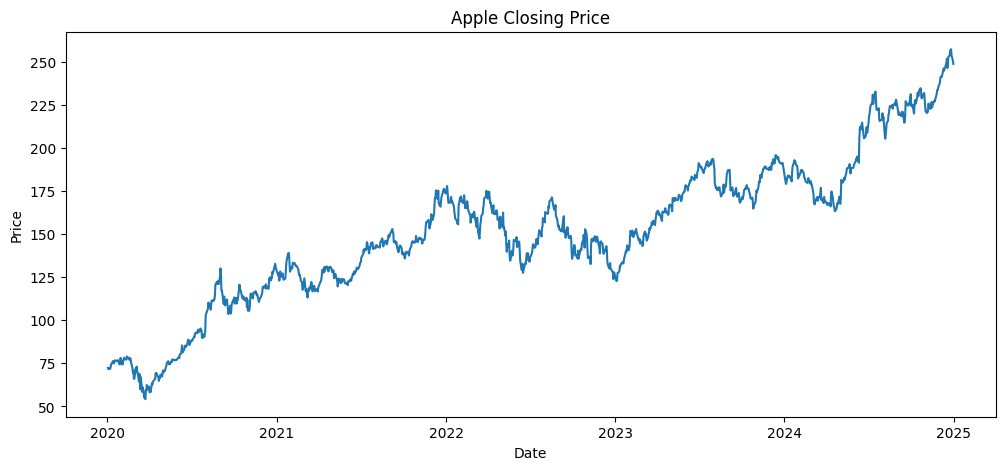

In [10]:
plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title("Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [11]:
from sklearn.preprocessing import MinMaxScaler

close_prices = data[['Close']]

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(close_prices)

print(scaled_data[:5])

[[0.0894149 ]
 [0.08595424]
 [0.08876306]
 [0.08709202]
 [0.09278065]]


In [12]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1198, 60)
(1198,)


In [13]:
print(X.shape)
print(y.shape)

(1198, 60)
(1198,)


In [14]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(X.shape)

(1198, 60, 1)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [16]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X.shape[1], 1)
    )
)

model.add(LSTM(units=50))

model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.fit(
    X,
    y,
    epochs=10,
    batch_size=32
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0191
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0014
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 8.8971e-04
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 8.8855e-04
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 8.4839e-04
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 7.7653e-04
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 7.8840e-04
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 7.4433e-04
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 7.4072e-04
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 6.9915e-04


In [19]:
model.save("apple_lstm_model.h5")

In [20]:
predictions = model.predict(X)

print(predictions[:5])

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
[[0.04972299]
 [0.04950877]
 [0.04985331]
 [0.04981028]
 [0.04971452]]


In [21]:
predictions = scaler.inverse_transform(predictions)

print(predictions[:5])

[[64.26801]
 [64.22448]
 [64.29449]
 [64.28575]
 [64.26629]]


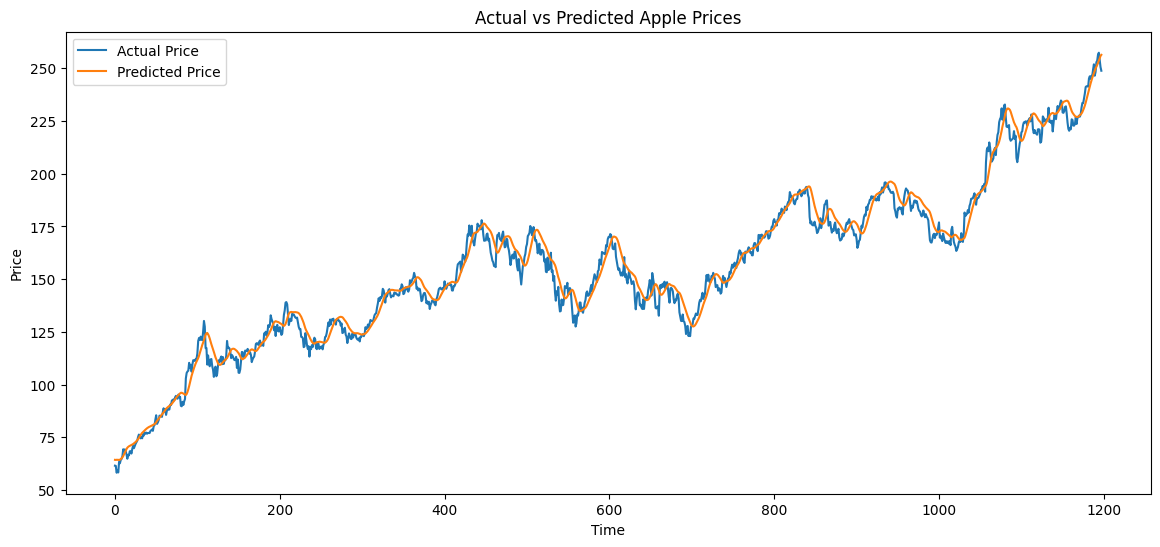

In [22]:
actual_prices = scaler.inverse_transform(
    y.reshape(-1,1)
)

plt.figure(figsize=(14,6))

plt.plot(actual_prices, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("Actual vs Predicted Apple Prices")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()

plt.show()

In [23]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(958, 60, 1)
(240, 60, 1)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model2 = Sequential()

model2.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

model2.add(LSTM(50))
model2.add(Dense(1))

model2.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
history = model2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0239 - val_loss: 0.0032
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0022 - val_loss: 0.0071
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0011 - val_loss: 0.0024
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 8.9751e-04 - val_loss: 0.0016
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 8.6276e-04 - val_loss: 0.0017
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 8.8661e-04 - val_loss: 0.0025
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 8.0062e-04 - val_loss: 0.0016
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 7.8597e-04 - val_loss: 0.0020
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 7.5238e-04 - val_loss: 0.0013
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 7.3347e-04 - val_loss: 0.0011


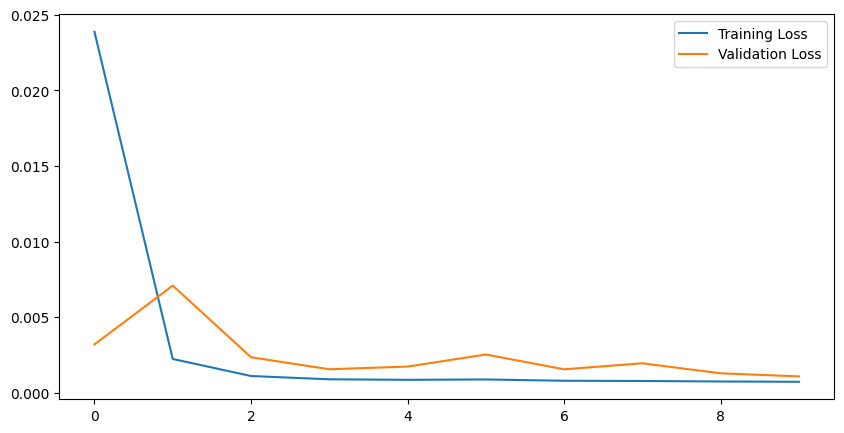

In [26]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.legend()
plt.show()

In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 5.331067164850487


In [28]:
last_60_days = scaled_data[-60:]

In [29]:
X_future = np.array([last_60_days])

print(X_future.shape)

(1, 60, 1)


In [30]:
future_price = model.predict(X_future)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [31]:
future_price = scaler.inverse_transform(future_price)

print("Predicted Next Day Price:", future_price[0][0])

Predicted Next Day Price: 256.54507


In [32]:
future_predictions = []
current_batch = scaled_data[-60:].reshape(1,60,1)

In [ ]:
for i in range(7):

    pred = model.predict(current_batch, verbose=0)

    future_predictions.append(pred[0][0])

    current_batch = np.append(
        current_batch[:,1:,:],
        [[pred]],
        axis=1
    )

In [35]:
print(future_predictions)
print(len(future_predictions))

[]
0


In [36]:
future_predictions = []

current_batch = scaled_data[-60:].reshape(1,60,1)

In [37]:
for i in range(7):

    pred = model.predict(current_batch, verbose=0)

    future_predictions.append(pred[0][0])

    current_batch = np.append(
        current_batch[:,1:,:],
        pred.reshape(1,1,1),
        axis=1
    )

In [38]:
print(future_predictions)
print(len(future_predictions))

[np.float32(0.995913), np.float32(0.99789023), np.float32(1.0003196), np.float32(1.003084), np.float32(1.0060899), np.float32(1.0092664), np.float32(1.0125604)]
7


In [39]:
print(len(future_predictions))

7


In [40]:
future_predictions = np.array(
    future_predictions
).reshape(-1,1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

print(future_predictions)

[[256.54507]
 [256.94687]
 [257.44052]
 [258.0023 ]
 [258.61313]
 [259.25864]
 [259.928  ]]


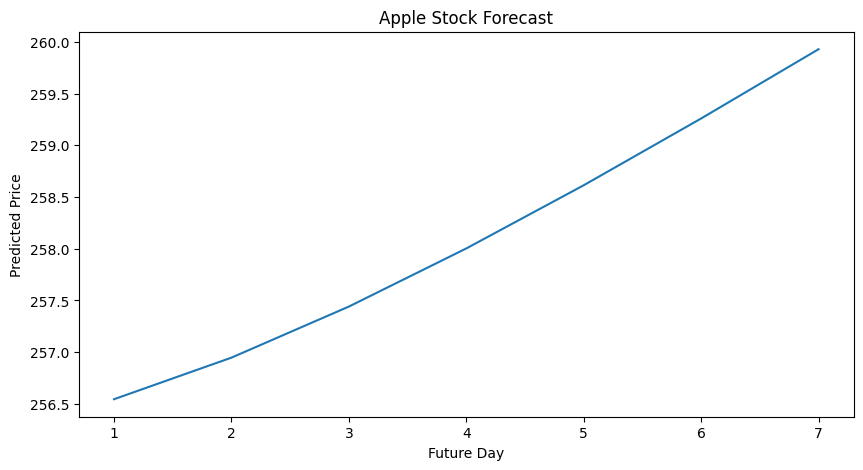

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    range(1,8),
    future_predictions
)

plt.title("Apple Stock Forecast")
plt.xlabel("Future Day")
plt.ylabel("Predicted Price")

plt.show()

In [42]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 5.331067164850487


In [44]:
model.save("apple_lstm_model.h5")

In [45]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [46]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(actual_prices, predictions)

print("MAE:", mae)

MAE: 4.214437831821346


In [47]:
from tensorflow.keras.layers import Dropout

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_dropout = Sequential()

model_dropout.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X.shape[1], 1)
    )
)

model_dropout.add(Dropout(0.2))

model_dropout.add(LSTM(50))

model_dropout.add(Dropout(0.2))

model_dropout.add(Dense(1))

model_dropout.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model_dropout.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
history = model_dropout.fit(
    X,
    y,
    epochs=10,
    batch_size=32
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0406
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0048
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0038
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0034
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0036
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0030
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0032
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0032
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0031
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0027
